# AI-Based Intrusion Detection Experiments


- removes duplicates **before** splitting;
- creates independent 70%/15%/15% train/validation/test sets;
- fits imputation, scaling and SHAP-guided feature refinement on training data only;
- implements genuine FFNN, 1D-CNN and LSTM neural networks;
- adds Logistic Regression and Random Forest conventional baselines;
- reports Accuracy, Precision, Recall, F1, F2, FPR, FNR and ROC-AUC;
- measures training and inference time;
- repeats experiments with multiple random seeds and calculates 95% confidence intervals;
- compares all features with SHAP-refined features;
- checks that train and test records do not overlap.



In [ ]:

!pip -q install shap lime pyarrow openpyxl

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---------------- USER SETTINGS ----------------
DATASET = 'cicids'

CICIDS_FOLDER = '/content/drive/MyDrive/CICIDS2017/'
UNSW_FOLDER = '/content/drive/MyDrive/UNSW-NB15/'
RESULTS_FOLDER = '/content/drive/MyDrive/IDS_Corrected_Results/'

QUICK_MODE = False
MAX_RECORDS = 100_000
SEEDS = [42, 43, 44, 45, 46]      # Five repeated runs for statistical reporting
TOP_FEATURES = 15                 # Maximum number kept after SHAP refinement
EPOCHS = 20
BATCH_SIZE = 512

print('Dataset:', DATASET)
print('Mode:', 'QUICK CHECK ONLY' if QUICK_MODE else 'FINAL EXPERIMENT')

Dataset: cicids
Mode: FINAL EXPERIMENT


In [ ]:
import os, sys, glob, time, json, platform, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
import shap

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
os.makedirs(RESULTS_FOLDER, exist_ok=True)

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('Scikit-learn:', sklearn.__version__)
print('TensorFlow:', tf.__version__)
print('SHAP:', shap.__version__)
print('Platform:', platform.platform())
print('CPU:', platform.processor() or 'Reported by Colab runtime')
print('GPU:', tf.config.list_physical_devices('GPU'))

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
TensorFlow: 2.20.0
SHAP: 0.52.0
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CPU: x86_64
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def load_file(path):
    extension = Path(path).suffix.lower()
    if extension == '.parquet':
        return pd.read_parquet(path)
    return pd.read_csv(path, low_memory=False)


def find_data_files(folder):
    files = sorted(glob.glob(os.path.join(folder, '*.csv')) +
                   glob.glob(os.path.join(folder, '*.parquet')))
    if not files:
        raise FileNotFoundError(
            f'No CSV or Parquet files were found in {folder}. '
            'Check the folder path in USER SETTINGS.'
        )
    return files


def load_dataset(dataset):
    folder = CICIDS_FOLDER if dataset == 'cicids' else UNSW_FOLDER
    files = find_data_files(folder)
    frames = []
    for file in files:
        print('Loading:', os.path.basename(file))
        part = load_file(file)
        part.columns = part.columns.astype(str).str.strip()
        frames.append(part)
    data = pd.concat(frames, ignore_index=True)

    if dataset == 'cicids':
        label_column = next((c for c in data.columns if c.lower() == 'label'), None)
        if label_column is None:
            raise ValueError('CICIDS label column was not found.')
        text_label = data[label_column].astype(str).str.strip().str.upper()
        data['binary_label'] = (text_label != 'BENIGN').astype(int)
    elif dataset == 'unsw':
        label_column = next((c for c in data.columns if c.lower() == 'label'), None)
        if label_column is None:
            raise ValueError('UNSW label column was not found.')
        data['binary_label'] = pd.to_numeric(data[label_column], errors='raise').astype(int)
    else:
        raise ValueError("DATASET must be 'cicids' or 'unsw'.")
    return data, files


df, source_files = load_dataset(DATASET)
raw_rows, raw_columns = df.shape
print(f'Raw records: {raw_rows:,}; raw columns: {raw_columns}')
print('Source files:', len(source_files))
print(df['binary_label'].value_counts().rename(index={0: 'Normal', 1: 'Attack'}))

Loading: combine.csv
Raw records: 2,214,469; raw columns: 80
Source files: 1
binary_label
Normal    1672837
Attack     541632
Name: count, dtype: int64


In [ ]:
# Remove exact duplicate rows before any train/test split.
before_duplicates = len(df)
df = df.drop_duplicates().reset_index(drop=True)
duplicates_removed = before_duplicates - len(df)
print(f'Exact duplicate rows removed: {duplicates_removed:,}')


def stratified_sample(data, target, n, seed=42):
    if n is None or len(data) <= n:
        return data.reset_index(drop=True)
    sampled, _ = train_test_split(
        data, train_size=n, random_state=seed, stratify=data[target]
    )
    return sampled.reset_index(drop=True)

working_limit = 20_000 if QUICK_MODE else MAX_RECORDS
df = stratified_sample(df, 'binary_label', working_limit, seed=42)
print(f'Records used in this run: {len(df):,}')

# Remove labels and identifiers that could directly reveal capture scenario or answer.
drop_names = {
    'label', 'binary_label', 'attack_cat', 'attack category', 'id', 'unnamed: 0',
    'flow id', 'source ip', 'destination ip', 'srcip', 'dstip', 'timestamp'
}
feature_columns = [c for c in df.columns if c.strip().lower() not in drop_names]
X_raw = df[feature_columns].copy()
y = df['binary_label'].astype(int).copy()

# The original prototype analysed numeric flow features. Non-numeric columns are documented and excluded.
non_numeric = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()
X_raw = X_raw.select_dtypes(include=[np.number]).copy()
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

if X_raw.shape[1] == 0:
    raise ValueError('No numeric input features remain after removing labels/identifiers.')

# Removing identifiers can make previously different rows identical as model inputs.
# Remove those duplicate feature vectors before splitting to prevent train/test overlap.
feature_duplicate_mask = X_raw.duplicated(keep='first')
feature_duplicates_removed = int(feature_duplicate_mask.sum())
X_raw = X_raw.loc[~feature_duplicate_mask].reset_index(drop=True)
y = y.loc[~feature_duplicate_mask].reset_index(drop=True)

print(f'Numeric features retained: {X_raw.shape[1]}')
print('Excluded non-numeric columns:', non_numeric)
print(f'Duplicate numeric feature vectors removed: {feature_duplicates_removed:,}')
print('Missing numeric values before imputation:', int(X_raw.isna().sum().sum()))

Exact duplicate rows removed: 271,598
Records used in this run: 100,000
Numeric features retained: 77
Excluded non-numeric columns: ['Destination Port']
Duplicate numeric feature vectors removed: 8,165
Missing numeric values before imputation: 96


In [ ]:
# Create 70% train, 15% validation and 15% test partitions.
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Check overlap using the raw selected feature rows.
train_hashes = set(pd.util.hash_pandas_object(X_train_raw, index=False).astype(str))
test_hashes = set(pd.util.hash_pandas_object(X_test_raw, index=False).astype(str))
overlap_count = len(train_hashes.intersection(test_hashes))

print(f'Train: {len(X_train_raw):,} ({len(X_train_raw)/len(X_raw):.1%})')
print(f'Validation: {len(X_val_raw):,} ({len(X_val_raw)/len(X_raw):.1%})')
print(f'Test: {len(X_test_raw):,} ({len(X_test_raw)/len(X_raw):.1%})')
print('Identical feature records shared by train and test:', overlap_count)

# Fit preprocessing ONLY on training data, then apply it to validation/test data.
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_raw)
X_val_imp = imputer.transform(X_val_raw)
X_test_imp = imputer.transform(X_test_raw)

X_train_all = scaler.fit_transform(X_train_imp).astype('float32')
X_val_all = scaler.transform(X_val_imp).astype('float32')
X_test_all = scaler.transform(X_test_imp).astype('float32')
all_feature_names = X_train_raw.columns.tolist()

assert overlap_count == 0, 'Leakage warning: identical feature records exist in train and test.'
print('Leakage-safe preprocessing completed.')

Train: 64,284 (70.0%)
Validation: 13,775 (15.0%)
Test: 13,776 (15.0%)
Identical feature records shared by train and test: 0
Leakage-safe preprocessing completed.


In [ ]:
print("Starting SHAP feature selection...")

# Faster Extra Trees selector
selector_model = ExtraTreesClassifier(
    n_estimators=60,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Extra Trees...")
selector_model.fit(X_train_all, np.asarray(y_train).ravel())
print("Extra Trees training completed.")

# Use only 300 training records for SHAP
sample_size = min(300, len(X_train_all))

rng = np.random.default_rng(42)
sample_indices = rng.choice(
    len(X_train_all),
    size=sample_size,
    replace=False
)

background_sample = X_train_all[sample_indices]

print(f"Calculating SHAP values using {sample_size} records...")

selector_explainer = shap.TreeExplainer(selector_model)

shap_values = selector_explainer.shap_values(
    background_sample,
    check_additivity=False
)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    attack_shap = np.asarray(shap_values[-1])
else:
    attack_shap = np.asarray(shap_values)

    # New SHAP versions may return:
    # records × features × classes
    if attack_shap.ndim == 3:
        attack_shap = attack_shap[:, :, -1]

shap_importance = np.mean(
    np.abs(attack_shap),
    axis=0
).reshape(-1)

# Safety check
if len(shap_importance) != len(all_feature_names):
    raise ValueError(
        f"SHAP produced {len(shap_importance)} importance values, "
        f"but the dataset has {len(all_feature_names)} features."
    )

ranking = pd.DataFrame({
    "Feature": all_feature_names,
    "MeanAbsoluteSHAP": shap_importance
}).sort_values(
    "MeanAbsoluteSHAP",
    ascending=False
).reset_index(drop=True)

n_refined = min(TOP_FEATURES, len(all_feature_names))

selected_features = ranking.head(n_refined)["Feature"].tolist()

selected_indices = [
    all_feature_names.index(feature)
    for feature in selected_features
]

X_train_refined = X_train_all[:, selected_indices]
X_val_refined = X_val_all[:, selected_indices]
X_test_refined = X_test_all[:, selected_indices]

reduction_percentage = (
    100 * (1 - n_refined / len(all_feature_names))
)

print("\nSelected SHAP features:")
print(ranking.head(n_refined).to_string(index=False))

print(
    f"\nFeature count: "
    f"{len(all_feature_names)} → {n_refined}"
)

print(
    f"Feature reduction: "
    f"{reduction_percentage:.2f}%"
)

ranking.to_csv(
    os.path.join(
        RESULTS_FOLDER,
        f"{DATASET}_shap_feature_ranking.csv"
    ),
    index=False
)

print("\nSHAP feature selection completed successfully.")

Starting SHAP feature selection...
Training Extra Trees...
Extra Trees training completed.
Calculating SHAP values using 300 records...

Selected SHAP features:
               Feature  MeanAbsoluteSHAP
Bwd Packet Length Mean          0.046849
     Packet Length Std          0.031171
  Avg Bwd Segment Size          0.028706
 Bwd Packet Length Max          0.027755
        ACK Flag Count          0.025462
    Packet Length Mean          0.023542
 Bwd Packet Length Std          0.021184
   Average Packet Size          0.019469
        URG Flag Count          0.017949
             Idle Mean          0.017490
 Bwd Packet Length Min          0.016420
     Max Packet Length          0.015016
           Fwd IAT Std          0.014865
        PSH Flag Count          0.011522
Packet Length Variance          0.010499

Feature count: 77 → 15
Feature reduction: 80.52%

SHAP feature selection completed successfully.


In [ ]:
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def build_cnn(n_features, seed):
    set_seed(seed)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features, 1)),
        tf.keras.layers.Conv1D(32, kernel_size=3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv1D(16, kernel_size=3, padding='same', activation='relu'),
        tf.keras.layers.GlobalMaxPooling1D(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_lstm(n_features, seed):
    set_seed(seed)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features, 1)),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def calculate_metrics(y_true, predictions, probabilities):
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        'Accuracy': accuracy_score(y_true, predictions),
        'Precision': precision_score(y_true, predictions, zero_division=0),
        'Recall': recall_score(y_true, predictions, zero_division=0),
        'F1': f1_score(y_true, predictions, zero_division=0),
        'F2': fbeta_score(y_true, predictions, beta=2, zero_division=0),
        'FPR': fp / (fp + tn) if fp + tn else 0.0,
        'FNR': fn / (fn + tp) if fn + tp else 0.0,
        'AUC': roc_auc_score(y_true, probabilities),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)
    }


def evaluate_sklearn(model, X_train, y_train, X_test, y_test):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start
    start = time.perf_counter()
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    inference_seconds = time.perf_counter() - start
    return calculate_metrics(y_test, predictions, probabilities), train_seconds, inference_seconds, probabilities


def evaluate_keras(model, X_train, y_train, X_val, y_val, X_test, y_test):
    Xtr = X_train[..., np.newaxis]
    Xv = X_val[..., np.newaxis]
    Xte = X_test[..., np.newaxis]
    callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )
    start = time.perf_counter()
    model.fit(
        Xtr, np.asarray(y_train), validation_data=(Xv, np.asarray(y_val)),
        epochs=5 if QUICK_MODE else EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[callback], verbose=0
    )
    train_seconds = time.perf_counter() - start
    start = time.perf_counter()
    probabilities = model.predict(Xte, batch_size=BATCH_SIZE, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    inference_seconds = time.perf_counter() - start
    return calculate_metrics(y_test, predictions, probabilities), train_seconds, inference_seconds, probabilities


print('Model functions ready.')

Model functions ready.


In [ ]:
all_rows = []
roc_store = {}
experiment_seeds = [42] if QUICK_MODE else SEEDS

feature_sets = {
    'All features': (X_train_all, X_val_all, X_test_all),
    'SHAP refined': (X_train_refined, X_val_refined, X_test_refined)
}

for feature_set_name, (Xtr, Xv, Xte) in feature_sets.items():
    print(f'\n===== {feature_set_name}: {Xtr.shape[1]} features =====')
    for seed in experiment_seeds:
        print('Seed:', seed)
        set_seed(seed)

        sklearn_models = {
            'Logistic Regression': LogisticRegression(
                max_iter=1000, random_state=seed, class_weight='balanced'
            ),
            'Random Forest': RandomForestClassifier(
                n_estimators=200 if not QUICK_MODE else 50,
                random_state=seed, n_jobs=-1, class_weight='balanced'
            ),
            'FFNN': MLPClassifier(
                hidden_layer_sizes=(128, 64, 32), activation='relu',
                max_iter=300, random_state=seed, early_stopping=True,
                validation_fraction=0.15
            )
        }

        for model_name, model in sklearn_models.items():
            metrics, train_time, infer_time, probabilities = evaluate_sklearn(
                model, Xtr, y_train, Xte, y_test
            )
            row = {'Dataset': DATASET.upper(), 'FeatureSet': feature_set_name,
                   'FeatureCount': Xtr.shape[1], 'Seed': seed, 'Model': model_name,
                   'TrainingSeconds': train_time, 'InferenceSeconds': infer_time, **metrics}
            all_rows.append(row)
            if seed == experiment_seeds[0]:
                roc_store[(feature_set_name, model_name)] = probabilities

        for model_name, builder in [('CNN', build_cnn), ('LSTM', build_lstm)]:
            tf.keras.backend.clear_session()
            model = builder(Xtr.shape[1], seed)
            metrics, train_time, infer_time, probabilities = evaluate_keras(
                model, Xtr, y_train, Xv, y_val, Xte, y_test
            )
            row = {'Dataset': DATASET.upper(), 'FeatureSet': feature_set_name,
                   'FeatureCount': Xtr.shape[1], 'Seed': seed, 'Model': model_name,
                   'TrainingSeconds': train_time, 'InferenceSeconds': infer_time, **metrics}
            all_rows.append(row)
            if seed == experiment_seeds[0]:
                roc_store[(feature_set_name, model_name)] = probabilities

results_runs = pd.DataFrame(all_rows)
display(results_runs.round(4))
results_runs.to_csv(os.path.join(RESULTS_FOLDER, f'{DATASET}_individual_runs.csv'), index=False)
print('Individual-run results saved.')


===== All features: 77 features =====
Seed: 42
Seed: 43
Seed: 44
Seed: 45
Seed: 46

===== SHAP refined: 15 features =====
Seed: 42
Seed: 43
Seed: 44
Seed: 45
Seed: 46


,Dataset,FeatureSet,FeatureCount,Seed,Model,TrainingSeconds,InferenceSeconds,Accuracy,Precision,Recall,F1,F2,FPR,FNR,AUC,TN,FP,FN,TP
0,CICIDS,All features,77,42,Logistic Regression,3.7730,0.0068,0.9427,0.7736,0.9757,0.8630,0.9273,0.0648,0.0243,0.9927,10498,728,62,2488
1,CICIDS,All features,77,42,Random Forest,22.1583,0.1399,0.9977,0.9953,0.9925,0.9939,0.9931,0.0011,0.0075,1.0000,11214,12,19,2531
2,CICIDS,All features,77,42,FFNN,18.4780,0.0362,0.9922,0.9785,0.9796,0.9790,0.9794,0.0049,0.0204,0.9989,11171,55,52,2498
3,CICIDS,All features,77,42,CNN,35.3726,0.6849,0.9864,0.9872,0.9384,0.9622,0.9478,0.0028,0.0616,0.9972,11195,31,157,2393
4,CICIDS,All features,77,42,LSTM,27.7825,0.3228,0.9741,0.9353,0.9239,0.9296,0.9262,0.0145,0.0761,0.9921,11063,163,194,2356
5,CICIDS,All features,77,43,Logistic Regression,5.2282,0.0230,0.9427,0.7736,0.9757,0.8630,0.9273,0.0648,0.0243,0.9927,10498,728,62,2488
6,CICIDS,All features,77,43,Random Forest,22.7274,0.1422,0.9978,0.9961,0.9922,0.9941,0.9929,0.0009,0.0078,1.0000,11216,10,20,2530
7,CICIDS,All features,77,43,FFNN,59.9328,0.0220,0.9944,0.9843,0.9855,0.9849,0.9853,0.0036,0.0145,0.9995,11186,40,37,2513
8,CICIDS,All features,77,43,CNN,29.3212,0.5956,0.9827,0.9902,0.9153,0.9513,0.9294,0.0020,0.0847,0.9970,11203,23,216,2334
9,CICIDS,All features,77,43,LSTM,26.4888,0.3373,0.9742,0.9485,0.9098,0.9287,0.9173,0.0112,0.0902,0.9939,11100,126,230,2320


Individual-run results saved.


In [ ]:
# Mean, standard deviation and 95% confidence intervals across repeated runs.
metric_columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'FPR', 'FNR',
                  'AUC', 'TrainingSeconds', 'InferenceSeconds']
group_columns = ['Dataset', 'FeatureSet', 'FeatureCount', 'Model']

summary_parts = []
for keys, group in results_runs.groupby(group_columns):
    row = dict(zip(group_columns, keys))
    n = len(group)
    row['Runs'] = n
    for metric in metric_columns:
        mean = group[metric].mean()
        std = group[metric].std(ddof=1) if n > 1 else 0.0
        ci = 1.96 * std / np.sqrt(n) if n > 1 else 0.0
        row[f'{metric}_Mean'] = mean
        row[f'{metric}_SD'] = std
        row[f'{metric}_CI95_Lower'] = mean - ci
        row[f'{metric}_CI95_Upper'] = mean + ci
    summary_parts.append(row)

summary = pd.DataFrame(summary_parts)
main_columns = group_columns + ['Runs'] + [f'{m}_Mean' for m in metric_columns]
display(summary[main_columns].round(4))
summary.to_csv(os.path.join(RESULTS_FOLDER, f'{DATASET}_statistical_summary.csv'), index=False)

# Direct EGFRF ablation comparison: refined minus all-feature mean results.
means = summary.set_index(['FeatureSet', 'Model'])
ablation_rows = []
for model_name in summary['Model'].unique():
    full = means.loc[('All features', model_name)]
    refined = means.loc[('SHAP refined', model_name)]
    ablation_rows.append({
        'Model': model_name,
        'FeaturesBefore': int(full['FeatureCount']),
        'FeaturesAfter': int(refined['FeatureCount']),
        'ReductionPercent': 100 * (1 - refined['FeatureCount'] / full['FeatureCount']),
        'AccuracyChange': refined['Accuracy_Mean'] - full['Accuracy_Mean'],
        'F1Change': refined['F1_Mean'] - full['F1_Mean'],
        'F2Change': refined['F2_Mean'] - full['F2_Mean'],
        'FPRChange': refined['FPR_Mean'] - full['FPR_Mean'],
        'FNRChange': refined['FNR_Mean'] - full['FNR_Mean'],
        'AUCChange': refined['AUC_Mean'] - full['AUC_Mean'],
        'TrainingTimeChangeSeconds': refined['TrainingSeconds_Mean'] - full['TrainingSeconds_Mean'],
        'InferenceTimeChangeSeconds': refined['InferenceSeconds_Mean'] - full['InferenceSeconds_Mean']
    })

ablation = pd.DataFrame(ablation_rows)
display(ablation.round(4))
ablation.to_csv(os.path.join(RESULTS_FOLDER, f'{DATASET}_egfrf_ablation.csv'), index=False)
print('Statistical summary and EGFRF comparison saved.')

,Dataset,FeatureSet,FeatureCount,Model,Runs,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,F2_Mean,FPR_Mean,FNR_Mean,AUC_Mean,TrainingSeconds_Mean,InferenceSeconds_Mean
0,CICIDS,All features,77,CNN,5,0.9831,0.9843,0.9237,0.9529,0.9352,0.0034,0.0763,0.9969,27.9346,0.6356
1,CICIDS,All features,77,FFNN,5,0.9932,0.9845,0.9786,0.9815,0.9798,0.0035,0.0214,0.9991,35.4572,0.0259
2,CICIDS,All features,77,LSTM,5,0.9645,0.9422,0.8603,0.8982,0.8748,0.0118,0.1397,0.9879,21.9231,0.3307
3,CICIDS,All features,77,Logistic Regression,5,0.9427,0.7736,0.9757,0.8630,0.9273,0.0648,0.0243,0.9927,4.1924,0.0147
4,CICIDS,All features,77,Random Forest,5,0.9978,0.9955,0.9924,0.9940,0.9930,0.0010,0.0076,1.0000,23.0882,0.1665
5,CICIDS,SHAP refined,15,CNN,5,0.9783,0.9659,0.9154,0.9398,0.9250,0.0074,0.0846,0.9960,17.6662,0.9789
6,CICIDS,SHAP refined,15,FFNN,5,0.9801,0.9631,0.9283,0.9454,0.9351,0.0081,0.0717,0.9967,45.2449,0.0542
7,CICIDS,SHAP refined,15,LSTM,5,0.9537,0.9834,0.7633,0.8588,0.7987,0.0030,0.2367,0.9862,21.2043,0.3084
8,CICIDS,SHAP refined,15,Logistic Regression,5,0.9111,0.6864,0.9573,0.7995,0.8872,0.0993,0.0427,0.9871,0.8534,0.0021
9,CICIDS,SHAP refined,15,Random Forest,5,0.9934,0.9817,0.9827,0.9822,0.9825,0.0042,0.0173,0.9984,11.0781,0.1395


,Model,FeaturesBefore,FeaturesAfter,ReductionPercent,AccuracyChange,F1Change,F2Change,FPRChange,FNRChange,AUCChange,TrainingTimeChangeSeconds,InferenceTimeChangeSeconds
0,CNN,77,15,80.5195,-0.0048,-0.0131,-0.0102,0.0040,0.0083,-0.0009,-10.2684,0.3434
1,FFNN,77,15,80.5195,-0.0130,-0.0361,-0.0447,0.0046,0.0503,-0.0024,9.7877,0.0283
2,LSTM,77,15,80.5195,-0.0108,-0.0394,-0.0761,-0.0088,0.0970,-0.0017,-0.7189,-0.0223
3,Logistic Regression,77,15,80.5195,-0.0315,-0.0634,-0.0400,0.0345,0.0184,-0.0056,-3.3390,-0.0125
4,Random Forest,77,15,80.5195,-0.0044,-0.0117,-0.0105,0.0032,0.0096,-0.0016,-12.0101,-0.0270


Statistical summary and EGFRF comparison saved.


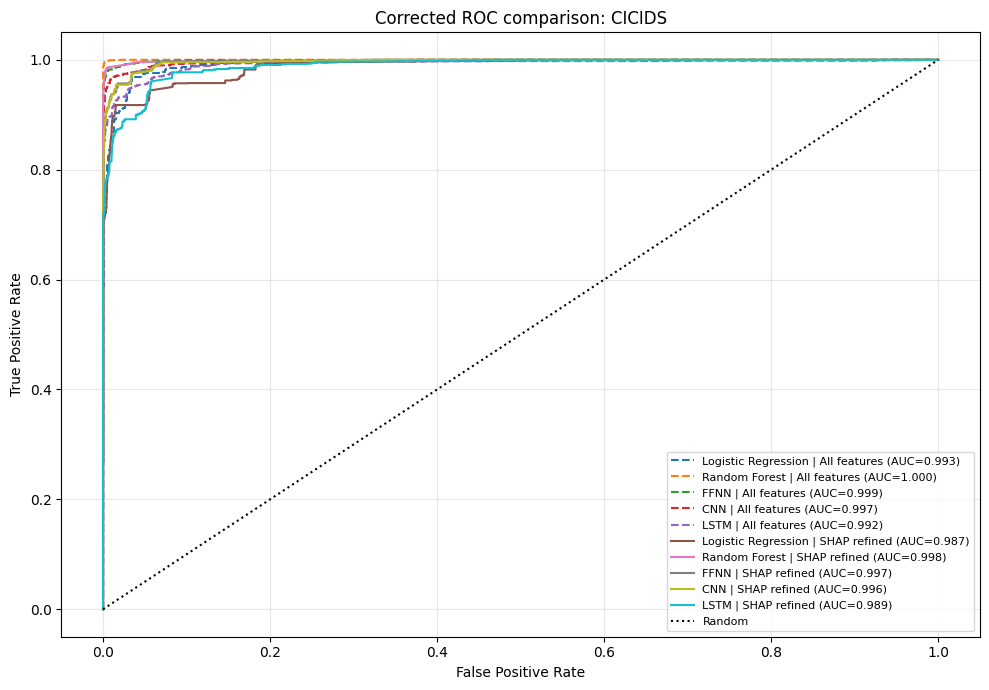

{
  "dataset": "cicids",
  "source_files": [
    "combine.csv"
  ],
  "raw_rows": 2214469,
  "rows_after_exact_duplicate_removal_before_sampling": 1942871,
  "exact_duplicates_removed": 271598,
  "duplicate_numeric_feature_vectors_removed": 8165,
  "records_used": 100000,
  "train_records": 64284,
  "validation_records": 13775,
  "test_records": 13776,
  "train_test_identical_feature_overlap": 0,
  "all_feature_count": 77,
  "refined_feature_count": 15,
  "feature_reduction_percent": 80.51948051948052,
  "seeds": [
    42,
    43,
    44,
    45,
    46
  ],
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "numpy": "2.0.2",
  "pandas": "2.2.2",
  "scikit_learn": "1.6.1",
  "tensorflow": "2.20.0",
  "shap": "0.52.0",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "gpu": [
    "PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')"
  ]
}

All results are saved in: /content/drive/MyDrive/IDS_Corrected_Results/


In [ ]:
# ROC curves from the first seed (repeated-run averages are in the summary table).
plt.figure(figsize=(10, 7))
for (feature_set, model_name), probabilities in roc_store.items():
    fpr_values, tpr_values, _ = roc_curve(y_test, probabilities)
    auc_value = roc_auc_score(y_test, probabilities)
    style = '-' if feature_set == 'SHAP refined' else '--'
    plt.plot(fpr_values, tpr_values, linestyle=style,
             label=f'{model_name} | {feature_set} (AUC={auc_value:.3f})')
plt.plot([0, 1], [0, 1], 'k:', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Corrected ROC comparison: {DATASET.upper()}')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(RESULTS_FOLDER, f'{DATASET}_corrected_roc.png')
plt.savefig(roc_path, dpi=200)
plt.show()

# Reproducibility record for the dissertation.
reproducibility = {
    'dataset': DATASET,
    'source_files': [os.path.basename(f) for f in source_files],
    'raw_rows': int(raw_rows),
    'rows_after_exact_duplicate_removal_before_sampling': int(before_duplicates - duplicates_removed),
    'exact_duplicates_removed': int(duplicates_removed),
    'duplicate_numeric_feature_vectors_removed': int(feature_duplicates_removed),
    'records_used': int(len(df)),
    'train_records': int(len(X_train_raw)),
    'validation_records': int(len(X_val_raw)),
    'test_records': int(len(X_test_raw)),
    'train_test_identical_feature_overlap': int(overlap_count),
    'all_feature_count': int(len(all_feature_names)),
    'refined_feature_count': int(len(selected_features)),
    'feature_reduction_percent': float(reduction_percentage),
    'seeds': experiment_seeds,
    'python': sys.version,
    'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit_learn': sklearn.__version__, 'tensorflow': tf.__version__, 'shap': shap.__version__,
    'platform': platform.platform(),
    'gpu': [str(x) for x in tf.config.list_physical_devices('GPU')]
}
with open(os.path.join(RESULTS_FOLDER, f'{DATASET}_reproducibility.json'), 'w') as file:
    json.dump(reproducibility, file, indent=2)

print(json.dumps(reproducibility, indent=2))
print('\nAll results are saved in:', RESULTS_FOLDER)

True class: Attack
Predicted class: Attack
Attack probability: 1.0

LIME feature contributions:
Bwd Packet Length Std > 0.07: +0.0428
Packet Length Variance > -0.25: +0.0366
Average Packet Size > 0.01: +0.0355
Packet Length Std > 0.10: +0.0287
Max Packet Length > 0.05: -0.0271
Bwd Packet Length Min <= -0.59: +0.0259
URG Flag Count <= -0.33: -0.0230
Packet Length Mean > 0.04: +0.0224
Bwd Packet Length Mean > -0.11: +0.0150
Fwd IAT Std > -0.23: +0.0147


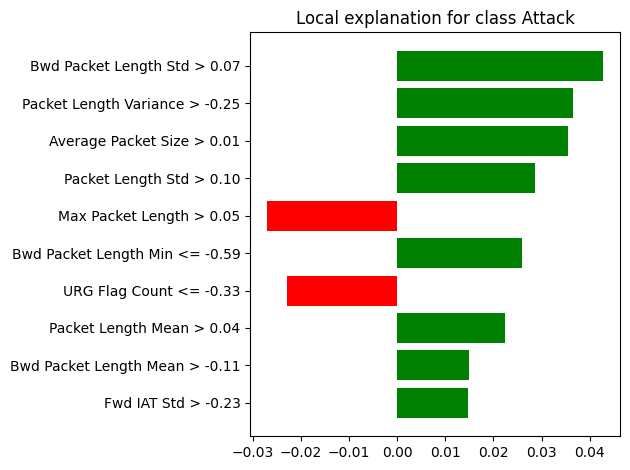

LIME PNG saved: /content/drive/MyDrive/IDS_Corrected_Results/cicids_lime_attack_explanation.png
LIME HTML saved: /content/drive/MyDrive/IDS_Corrected_Results/cicids_lime_attack_explanation.html


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# Train the strongest refined model for the LIME explanation
lime_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

lime_model.fit(X_train_refined, y_train)

# Create the LIME explainer
lime_explainer = LimeTabularExplainer(
    X_train_refined,
    feature_names=selected_features,
    class_names=["Normal", "Attack"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Select one correctly detected attack from the test data
probabilities = lime_model.predict_proba(X_test_refined)[:, 1]
predictions = (probabilities >= 0.5).astype(int)

correct_attacks = np.where(
    (np.asarray(y_test) == 1) & (predictions == 1)
)[0]

sample_index = correct_attacks[0]

lime_result = lime_explainer.explain_instance(
    X_test_refined[sample_index],
    lime_model.predict_proba,
    num_features=min(10, len(selected_features))
)

print("True class: Attack")
print("Predicted class:", "Attack" if predictions[sample_index] == 1 else "Normal")
print("Attack probability:", round(probabilities[sample_index], 4))

print("\nLIME feature contributions:")
for feature, contribution in lime_result.as_list():
    print(f"{feature}: {contribution:+.4f}")

# Save visual and interactive explanations
figure = lime_result.as_pyplot_figure()
plt.tight_layout()

lime_png = os.path.join(
    RESULTS_FOLDER,
    f"{DATASET}_lime_attack_explanation.png"
)
plt.savefig(lime_png, dpi=200, bbox_inches="tight")
plt.show()

lime_html = os.path.join(
    RESULTS_FOLDER,
    f"{DATASET}_lime_attack_explanation.html"
)
lime_result.save_to_file(lime_html)

print("LIME PNG saved:", lime_png)
print("LIME HTML saved:", lime_html)